# Correlação entre HRV e SUS

Este notebook calcula somente correlações de Spearman entre HRV e SUS para os 11 participantes `USAB-*`.

São comparadas duas formas: **HRV absoluta** da condição e **HRV corrigida pelo baseline**, calculada como `HRV da condição - HRV baseline` do mesmo participante. Stage 1 é associado apenas ao SUS Stage 1; Stage 8, apenas ao SUS Stage 8.

## Preperação do ambiente virtual

Instalando bibliotecas e fazendo download do que é necessário para rodar aplicação em nuvem.

In [ ]:
# Setup para Google Colab

import sys
from pathlib import Path

NO_COLAB = "google.colab" in sys.modules

if NO_COLAB:
    !git clone https://github.com/biancacmendes/PolarH10.git
    %cd SEU_REPOSITORIO
    !pip install -q -r requirements.txt

## Método

O ECG é processado pelas classes existentes para obter picos R, intervalos NN e as métricas HRV. O SUS também é calculado pela classe existente. A correlação de Spearman avalia associação monotônica pela ordem dos valores, sem exigir normalidade ou relação linear.

A tabela final apresenta `rho`, `p_valor` e `n_observacoes` para as análises absoluta e corrigida.

In [ ]:
from contextlib import redirect_stdout
from io import StringIO
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from src.analisador_correlacao import AnalisadorCorrelacao
from src.processador_dataset import ProcessadorDataset
from src.analisador_hrv import AnalisadorHRV
from src.analisador_sus import AnalisadorSUS
from src.carregador_dados import CarregadorDados
from src.processador_ecg import ProcessadorECG

In [ ]:
DIRETORIO_DADOS = Path("dataset")


# Identificação dos participantes

participantes = []

for pasta in DIRETORIO_DADOS.iterdir():

    if pasta.is_dir() and pasta.name.startswith("USAB-"):
        participantes.append(pasta.name)

participantes = sorted(participantes)


# Métricas de HRV analisadas

metricas_hrv = [
    "hr_bpm",
    "rmssd_ms",
    "sdnn_ms",
    "mf_ms2",
    "hf_ms2",
    "mf_medio_janelas_ms2",
    "mf_p95_ms2",
    "mfp95_mean",
]


# Nomes utilizados na apresentação dos resultados

nomes_metricas = {
    "hr_bpm": "HR",
    "rmssd_ms": "RMSSD",
    "sdnn_ms": "SDNN",
    "mf_ms2": "MF",
    "hf_ms2": "HF",
    "mf_medio_janelas_ms2": "MF médio",
    "mf_p95_ms2": "MF P95",
    "mfp95_mean": "MF P95/Mean",
}

Processamento dos dados de HRV e SUS

Nesta etapa, os dados de todos os participantes são processados de forma consolidada.

Para cada participante e condição experimental (Baseline, Stage 1 e Stage 8), o sinal de ECG é processado para obtenção dos intervalos NN. A partir desses intervalos são calculadas as métricas de HRV definidas na metodologia. Os resultados são reunidos em df_hrv, contendo uma observação para cada participante e condição experimental.

Em seguida, os questionários SUS são processados para as condições Stage 1 e Stage 8, e os respectivos escores são reunidos em df_sus.

Ao final desta etapa, são obtidos dois conjuntos de dados:

* df_hrv: métricas fisiológicas de cada participante nas três condições experimentais;
* df_sus: escores de usabilidade de cada participante em Stage 1 e Stage 8.

Esses conjuntos são utilizados nas etapas seguintes para comparação entre condições, correção das métricas de HRV pelo baseline e análise da associação entre HRV e SUS.

In [ ]:
processador_dataset = ProcessadorDataset(
    DIRETORIO_DADOS
)

df_hrv = processador_dataset.processar_todos()

analisador_sus = AnalisadorSUS(
    DIRETORIO_DADOS
)

resultados_sus = []

for participante in participantes:

    resultado = analisador_sus.analisar_participante(
        participante
    )

    resultados_sus.extend(
        resultado
    )

df_sus = pd.DataFrame(
    resultados_sus
)

Processando: USAB-AL-05
Processando: USAB-AL-07
Processando: USAB-ALM-10
Processando: USAB-BC-03
Processando: USAB-BL-08
Processando: USAB-DC-02
Processando: USAB-GS-06
Processando: USAB-GV-04
Processando: USAB-JPA-01
Processando: USAB-MEN-09
Processando: USAB-MR-11


## Preparação dos pares

O merge utiliza `participante` e `condicao`, garantindo que cada métrica HRV seja associada ao SUS da mesma pessoa e do mesmo Stage.

In [ ]:
estagios = df_hrv[
    df_hrv["condicao"].isin(
        ["stage_1", "stage_8"]
    )
].copy()

dados_absolutos = estagios.merge(
    df_sus,
    on=["participante", "condicao"],
    validate="one_to_one",
)

dados_corrigidos = (
    processador_dataset.calcular_variacao_baseline(
        df_hrv
    )
)

dados_corrigidos = dados_corrigidos.merge(
    df_sus,
    on=["participante", "condicao"],
    validate="one_to_one",
)

## Correlações de Spearman

`rho` positivo indica tendência de valores maiores de HRV acompanharem SUS maior; `rho` negativo indica tendência inversa. A análise absoluta descreve o nível observado. A análise corrigida descreve a mudança em relação ao repouso individual.

In [ ]:
analisador_correlacao = AnalisadorCorrelacao()

tabela_correlacoes = analisador_correlacao.calcular_correlacoes(
    dados_absolutos,
    dados_corrigidos,
    nomes_metricas,
)

tabela_correlacoes

,metrica,analise,rho,p_valor,n_observacoes
0,HR,Absoluta,-0.236761,0.288752,22
1,HR,Corrigida pelo baseline,0.050977,0.821751,22
2,RMSSD,Absoluta,-0.320024,0.146520,22
3,RMSSD,Corrigida pelo baseline,-0.013028,0.954115,22
4,SDNN,Absoluta,-0.208441,0.351913,22
5,SDNN,Corrigida pelo baseline,0.002266,0.992016,22
6,MF,Absoluta,-0.173889,0.438973,22
7,MF,Corrigida pelo baseline,0.135373,0.548061,22
8,HF,Absoluta,-0.292270,0.186873,22
9,HF,Corrigida pelo baseline,-0.120646,0.592781,22


## Visualização das correlações espectrais

MF, MF P95 e MF P95/Mean são destacadas para comparar visualmente as associações absolutas e corrigidas pelo baseline.

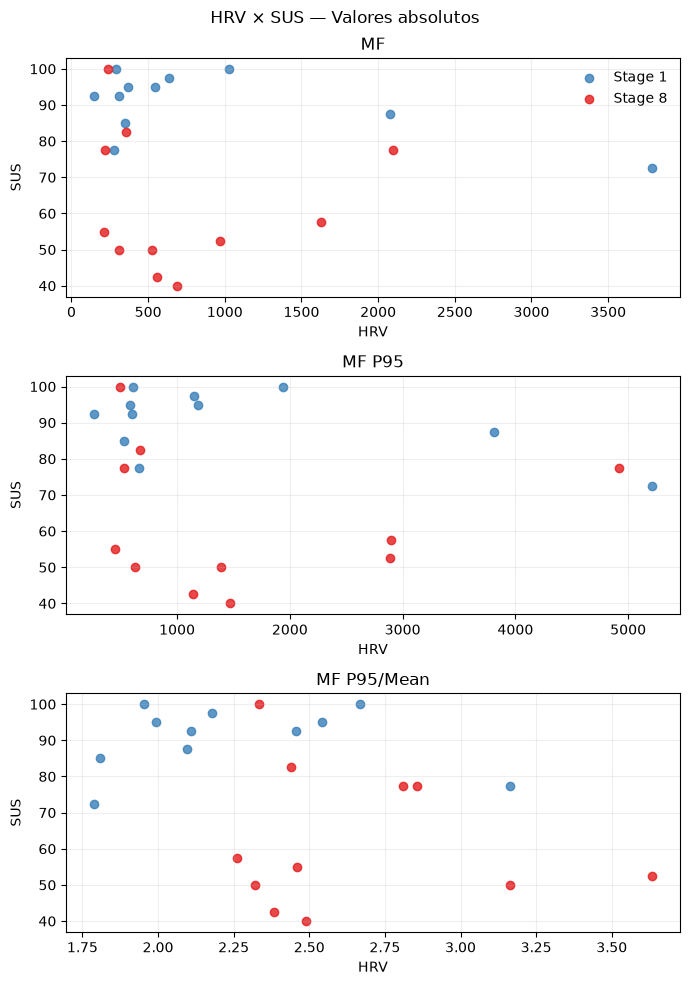

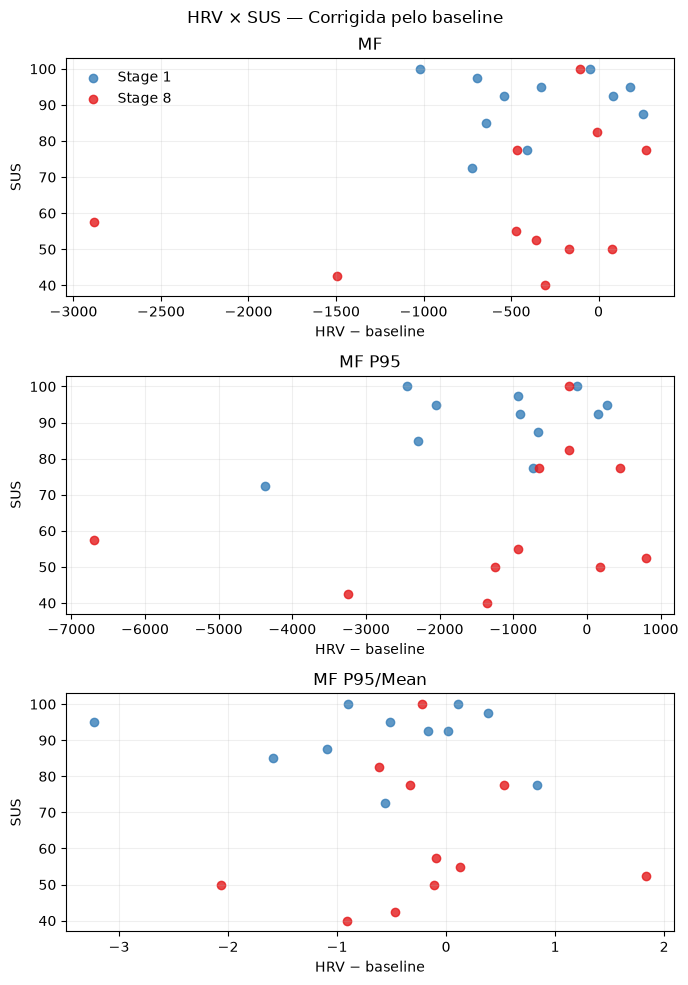

In [ ]:
# Métricas apresentadas nos gráficos

destaques = [
    "mf_ms2",
    "mf_p95_ms2",
    "mfp95_mean",
]

cores = {
    "stage_1": "#377eb8",
    "stage_8": "#e41a1c",
}


# Valores absolutos

fig, axes = plt.subplots(3, 1, figsize=(7, 10))

for ax, metrica in zip(axes, destaques):

    for condicao, grupo in dados_absolutos.groupby("condicao"):

        ax.scatter(
            grupo[metrica],
            grupo["sus_score"],
            color=cores[condicao],
            label=condicao.replace("stage_", "Stage "),
            alpha=0.8,
        )

    ax.set_title(nomes_metricas[metrica])
    ax.set_xlabel("HRV")
    ax.set_ylabel("SUS")
    ax.grid(alpha=0.2)

axes[0].legend(frameon=False)

fig.suptitle("HRV × SUS — Valores absolutos")
fig.tight_layout()

plt.show()


# Valores corrigidos pelo baseline

fig, axes = plt.subplots(3, 1, figsize=(7, 10))

for ax, metrica in zip(axes, destaques):

    coluna_corrigida = f"{metrica}_corrigida"

    for condicao, grupo in dados_corrigidos.groupby("condicao"):

        ax.scatter(
            grupo[coluna_corrigida],
            grupo["sus_score"],
            color=cores[condicao],
            label=condicao.replace("stage_", "Stage "),
            alpha=0.8,
        )

    ax.set_title(nomes_metricas[metrica])
    ax.set_xlabel("HRV − baseline")
    ax.set_ylabel("SUS")
    ax.grid(alpha=0.2)

axes[0].legend(frameon=False)

fig.suptitle("HRV × SUS — Corrigida pelo baseline")
fig.tight_layout()

plt.show()


Compare as duas linhas da tabela para observar como a subtração do baseline modifica `rho` e `p_valor`. Não são realizadas outras comparações ou testes neste notebook.

Comparação das métricas temporais de HRV

Nesta etapa são comparadas as médias de HR, RMSSD e SDNN entre o Stage 1 e o Stage 8.

A visualização é apresentada de duas formas:

* Valores absolutos: média das métricas obtidas diretamente em cada condição experimental.
* Variação em relação ao baseline: média da diferença entre o valor obtido em cada estágio e o baseline do mesmo participante:

$$
\Delta HRV = HRV_{\mathrm{Stage}} - HRV_{\mathrm{Baseline}}
$$

No gráfico corrigido pelo baseline, valores positivos indicam aumento da métrica em relação ao repouso, enquanto valores negativos indicam redução.

Essa comparação permite observar tanto as diferenças absolutas entre as condições quanto as alterações fisiológicas em relação ao estado basal dos participantes.

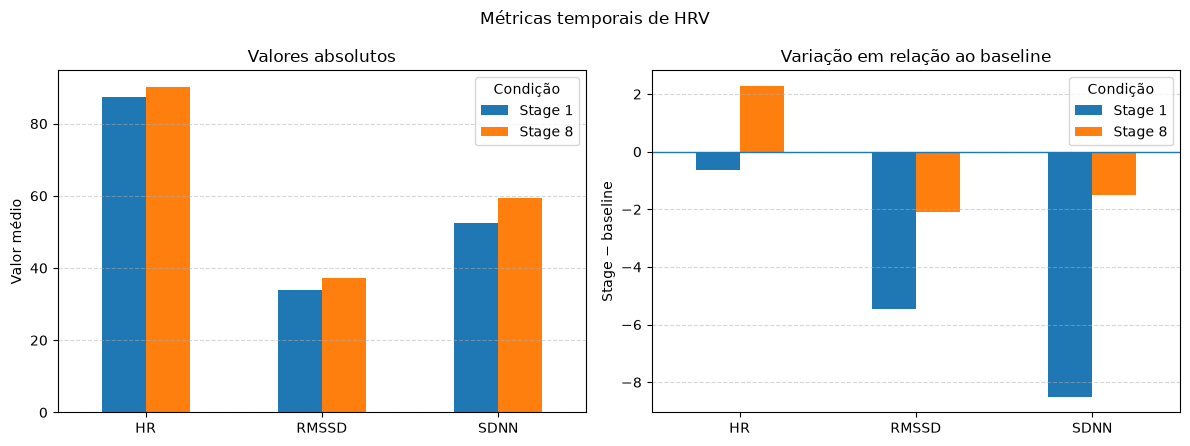

In [ ]:
metricas_tempo = [
    "hr_bpm",
    "rmssd_ms",
    "sdnn_ms",
]


# Valores absolutos

medias_absolutas = (
    dados_absolutos
    .groupby("condicao")[metricas_tempo]
    .mean()
)

medias_absolutas = medias_absolutas.rename(
    index={
        "stage_1": "Stage 1",
        "stage_8": "Stage 8",
    },
    columns=nomes_metricas,
)


# Valores corrigidos pelo baseline

metricas_corrigidas = [
    f"{metrica}_corrigida"
    for metrica in metricas_tempo
]

medias_corrigidas = (
    dados_corrigidos
    .groupby("condicao")[metricas_corrigidas]
    .mean()
)

medias_corrigidas.columns = [
    nomes_metricas[metrica]
    for metrica in metricas_tempo
]

medias_corrigidas = medias_corrigidas.rename(
    index={
        "stage_1": "Stage 1",
        "stage_8": "Stage 8",
    }
)


# Gráficos

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

medias_absolutas.T.plot(
    kind="bar",
    ax=axes[0],
)

medias_corrigidas.T.plot(
    kind="bar",
    ax=axes[1],
)

axes[0].set_title("Valores absolutos")
axes[0].set_ylabel("Valor médio")
axes[0].set_xlabel("")

axes[1].set_title("Variação em relação ao baseline")
axes[1].set_ylabel("Stage − baseline")
axes[1].set_xlabel("")
axes[1].axhline(0, linewidth=1)

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend(title="Condição", frameon=True)

fig.suptitle("Métricas temporais de HRV")
fig.tight_layout()

plt.show()

Comparação das métricas espectrais de HRV

Nesta etapa são comparadas as médias das componentes espectrais MF (0,07–0,15 Hz) e HF (0,15–0,40 Hz) entre o Stage 1 e o Stage 8.

A comparação é apresentada considerando:

* Valores absolutos: potência espectral média obtida diretamente em cada condição experimental, expressa em $\mathrm{ms}^2$.
* Variação em relação ao baseline: diferença entre a potência observada em cada estágio e o respectivo baseline de cada participante.

A correção pelo baseline é calculada individualmente como:

$$
\Delta P = P_{\mathrm{Stage}} - P_{\mathrm{Baseline}}
$$

onde $P$ representa a potência espectral da banda analisada.

No gráfico corrigido, valores positivos indicam aumento da potência espectral em relação ao baseline, enquanto valores negativos indicam redução. Essa visualização permite comparar o comportamento médio das componentes MF e HF entre as duas condições experimentais, considerando tanto seus valores absolutos quanto suas alterações em relação ao estado basal.

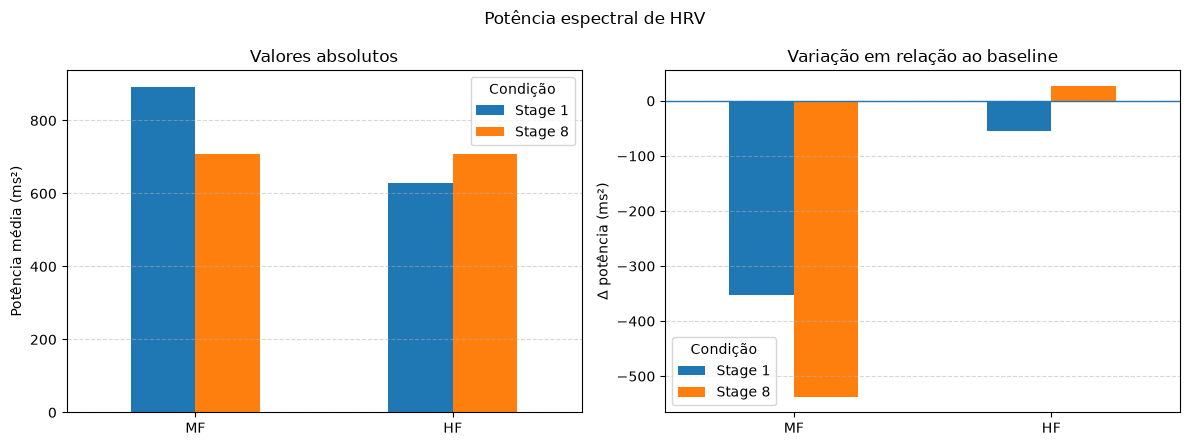

In [ ]:
metricas_frequencia = [
    "mf_ms2",
    "hf_ms2",
]


# Valores absolutos

medias_absolutas = (
    dados_absolutos
    .groupby("condicao")[metricas_frequencia]
    .mean()
)

medias_absolutas = medias_absolutas.rename(
    index={
        "stage_1": "Stage 1",
        "stage_8": "Stage 8",
    },
    columns=nomes_metricas,
)


# Valores corrigidos pelo baseline

metricas_corrigidas = [
    f"{metrica}_corrigida"
    for metrica in metricas_frequencia
]

medias_corrigidas = (
    dados_corrigidos
    .groupby("condicao")[metricas_corrigidas]
    .mean()
)

medias_corrigidas.columns = [
    nomes_metricas[metrica]
    for metrica in metricas_frequencia
]

medias_corrigidas = medias_corrigidas.rename(
    index={
        "stage_1": "Stage 1",
        "stage_8": "Stage 8",
    }
)


# Gráficos

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

medias_absolutas.T.plot(
    kind="bar",
    ax=axes[0],
)

medias_corrigidas.T.plot(
    kind="bar",
    ax=axes[1],
)

axes[0].set_title("Valores absolutos")
axes[0].set_ylabel("Potência média (ms²)")
axes[0].set_xlabel("")

axes[1].set_title("Variação em relação ao baseline")
axes[1].set_ylabel("Δ potência (ms²)")
axes[1].set_xlabel("")
axes[1].axhline(0, linewidth=1)

for ax in axes:
    ax.tick_params(axis="x", rotation=0)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.legend(title="Condição", frameon=True)

fig.suptitle("Potência espectral de HRV")
fig.tight_layout()

plt.show()

Comparação dos escores SUS

Nesta etapa é realizada uma comparação exploratória da usabilidade percebida entre o Stage 1 e o Stage 8, utilizando os escores obtidos pelo System Usability Scale (SUS).

Para cada condição experimental, é calculado o SUS médio dos participantes. O escore SUS varia de 0 a 100, sendo que valores mais elevados representam uma avaliação mais favorável da usabilidade percebida.

O gráfico de barras permite visualizar a diferença média entre as duas condições experimentais e comparar essa tendência subjetiva com as alterações observadas posteriormente nas métricas fisiológicas de HRV.

Esta etapa possui caráter descritivo e exploratório; o gráfico apresenta as médias observadas e, isoladamente, não constitui um teste de diferença estatística entre as condições.

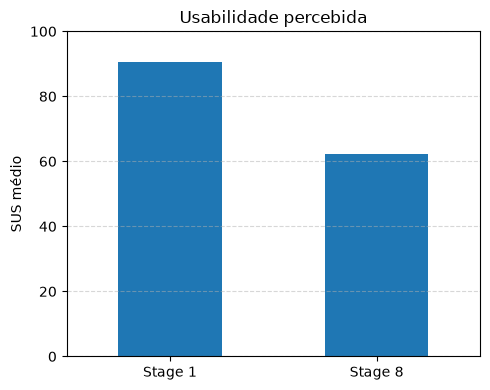

In [ ]:
media_sus = (
    df_sus[
        df_sus["condicao"].isin(["stage_1", "stage_8"])
    ]
    .groupby("condicao")["sus_score"]
    .mean()
)

media_sus = media_sus.rename(
    index={
        "stage_1": "Stage 1",
        "stage_8": "Stage 8",
    }
)

media_sus.plot(
    kind="bar",
    figsize=(5, 4),
)

plt.ylabel("SUS médio")
plt.xlabel("")
plt.title("Usabilidade percebida")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()